In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors

import getpass
import act

In [2]:
# Check for env variables, otherwise set your username and token here!
if "ARM_USERNAME" in os.environ:
    arm_username = os.getenv("ARM_USERNAME")
else:
    arm_username = input("Enter ARM username: ").strip()
if "ARM_TOKEN" in os.environ:
    arm_token = os.getenv("ARM_TOKEN")
else:
    arm_token = getpass.getpass("Enter ARM token (hidden): ").strip()

# Set the datastream and start/enddates
tropoe_datastream = 'nsatropoeC1.c1'

startdate = '2015-06-13'
enddate = '2015-06-13'

result_tropoe = act.discovery.download_arm_data(arm_username, arm_token, tropoe_datastream, startdate, enddate)

Enter ARM username:  qyzhang
Enter ARM token (hidden):  ········


[DOWNLOADING] nsatropoeC1.c1.20150613.001002.nc

If you use these data to prepare a publication, please cite:

Turner, D. Tropospheric Optimal Estimation Retrieval (TROPOE), 2015-06-13 to
2015-06-13, North Slope Alaska (NSA), Central Facility, Barrow AK (C1).
Atmospheric Radiation Measurement (ARM) User Facility.
https://doi.org/10.5439/1996977



In [5]:
# Let's read in the data using ACT and check out the data
ds_tropoe = act.io.read_arm_netcdf(result_tropoe)
ds_tropoe.clean.cleanup()

# We can also use xarray's built in slicing to quickly subset the data.  
# Let's look at some suspect data points in the temperature data
ds_tropoe = ds_tropoe.sel(time=slice('2015-06-13T22:00', '2015-06-14T00:00'))

In [9]:
ds_tropoe

<xarray.Dataset> Size: 2MB
Dimensions:                    (time: 13, height: 55, gas_dim: 3, dfs_dim: 16,
                                obs_dim: 455, arb_dim1: 123, arb_dim2: 123)
Coordinates:
  * time                       (time) datetime64[ns] 104B 2015-06-13T22:45:02...
  * height                     (height) float32 220B 0.0 0.01 ... 15.52 17.09
Dimensions without coordinates: gas_dim, dfs_dim, obs_dim, arb_dim1, arb_dim2
Data variables: (12/87)
    base_time                  object 8B ...
    time_offset                (time) float64 104B dask.array<chunksize=(13,), meta=np.ndarray>
    hour                       (time) object 104B dask.array<chunksize=(13,), meta=np.ndarray>
    qc_flag                    (time) int16 26B dask.array<chunksize=(13,), meta=np.ndarray>
    temperature                (time, height) float32 3kB dask.array<chunksize=(1, 55), meta=np.ndarray>
    waterVapor                 (time, height) float32 3kB dask.array<chunksize=(1, 55), meta=np.ndarray>
    ...                         ...
    Xop                        (time, arb_dim1) float32 6kB dask.array<chunksize=(1, 123), meta=np.ndarray>
    Sop                        (time, arb_dim1, arb_dim2) float32 787kB dask.array<chunksize=(1, 123, 123), meta=np.ndarray>
    Akernal                    (time, arb_dim1, arb_dim2) float32 787kB dask.array<chunksize=(1, 123, 123), meta=np.ndarray>
    lat                        float32 4B ...
    lon                        float32 4B ...
    alt                        float32 4B ...
Attributes: (12/245)
    algorithm_code:                                 TROPoe Retrieval Code (fo...
    algorithm_authors:                              Dave Turner, NOAA Global ...
    algorithm_comment1:                             TROPoe is a physical-iter...
    algorithm_comment2:                             Original code was written...
    algorithm_comment3:                             Code was ported to python...
    algorithm_disclaimer:                           TROPoe was developed by N...
    ...                                             ...
    VIP_zgrid:                                      0.000, 0.010, 0.021, 0.03...
    Total_clock_execution_time_in_s:                36726.174379
    _file_dates:                                    ['20150613']
    _file_times:                                    ['001002']
    _datastream:                                    act_datastream
    _arm_standards_flag:                            0

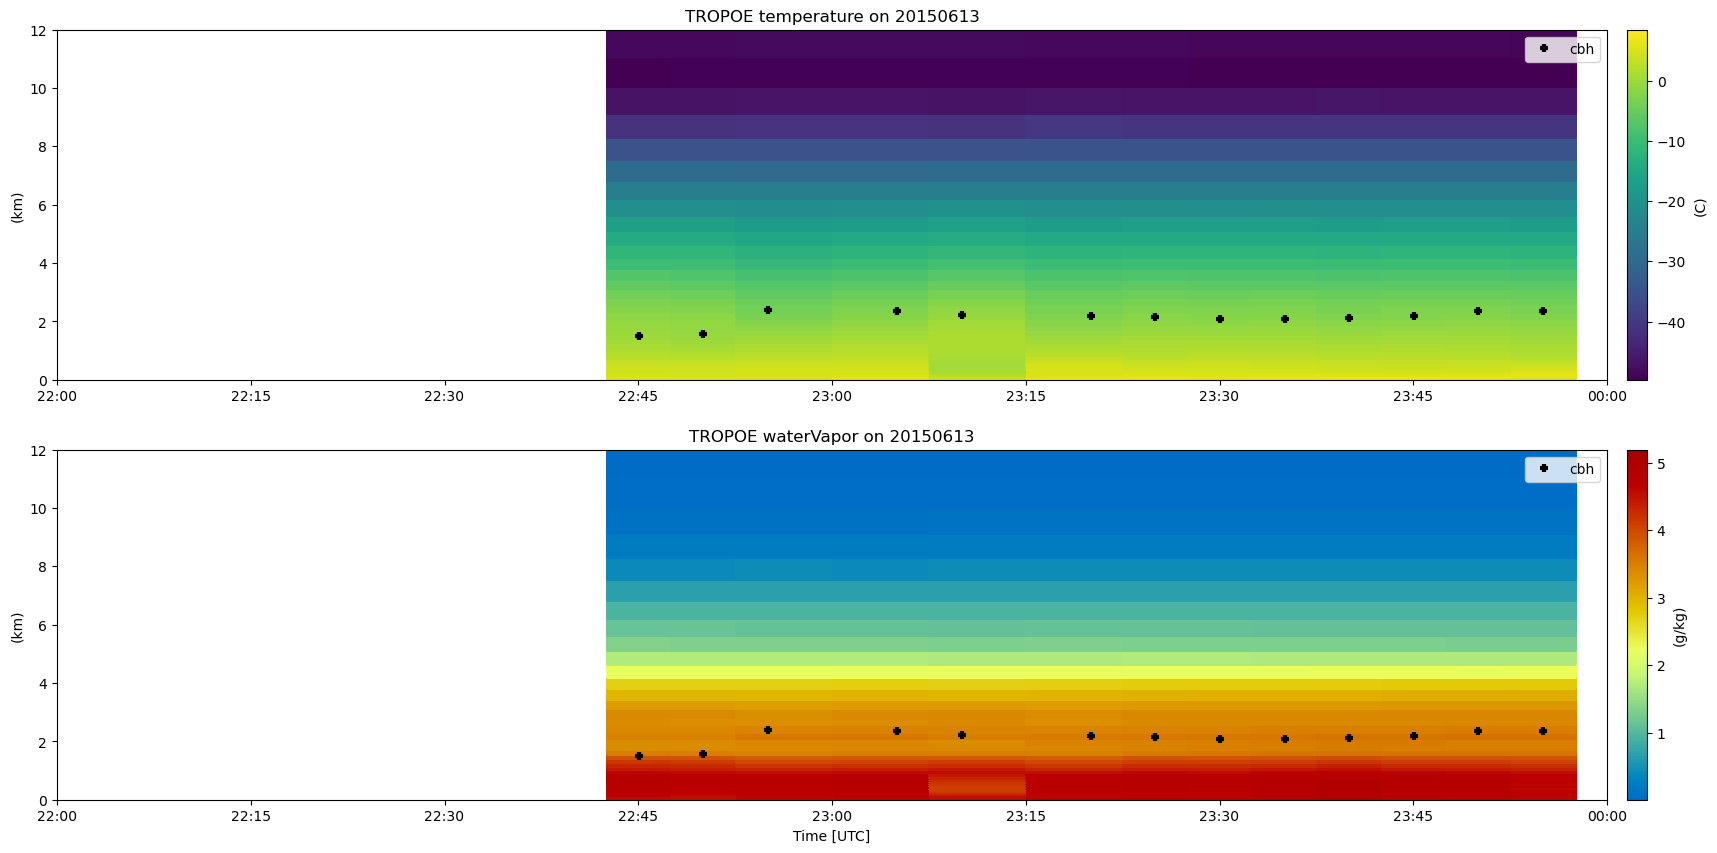

In [12]:

# Plot the AERI temperature and watervapor profile
 # Create a TimeSeriesDisplay object
display = act.plotting.TimeSeriesDisplay(
    {'TROPOE': ds_tropoe}, subplot_shape=(2,), figsize=(20, 10)
)

# Plot data
display.plot(
    'cbh',
    dsname='TROPOE',
    marker='+',
    color='black',
    markeredgewidth=3,
    linewidth=0,
    subplot_index=(0,),
    label='cbh',
)

display.plot(
    'temperature',
    dsname='TROPOE',
    cmap='viridis',
    set_shading='nearest',
    add_nan=True,
    subplot_index=(0,),
)

display.plot(
    'cbh',
    dsname='TROPOE',
    marker='+',
    color='black',
    markeredgewidth=3,
    linewidth=0,
    subplot_index=(1,),
    label='cbh',
)
display.plot(
    'waterVapor',
    dsname='TROPOE',
    cmap='HomeyerRainbow',
    set_shading='nearest',
    add_nan=True,
    subplot_index=(1,),
)

display.axes[0].set_ylim(bottom=0, top=12)
display.axes[1].set_ylim(bottom=0, top=12)

display.axes[0].set_xlim([np.datetime64('2015-06-13T22:00'), np.datetime64('2015-06-14T00:00')])
display.axes[1].set_xlim([np.datetime64('2015-06-13T22:00'), np.datetime64('2015-06-14T00:00')])

# If you want to save it you can
plt.savefig('20150613.png')
plt.show()